<a href="https://colab.research.google.com/github/AMujahid843/Project-2-STQD6014-Data-Science-P166974-/blob/main/Project_2_STQD6014_Data_Science(P166974).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PROJECT 2 STQD6014 DATA SCIENCE (P166974)**

##**INTRODUCTION**

<p align="justify">
&nbsp;&nbsp;&nbsp;&nbsp;Association of Southeast Asean Nations (ASEAN) is a bloc of 11 nations from Southeast Asia that is first established in 1967 to promote economic growth, social progress and political stability. On 26th October 2025, Timor-Leste made history by becoming the latest member of the ASEAN, finally ending its long wait to join the organization since gaining independence in 2022 (asean.org). Since one of ASEAN’s primary objectives is to promote economic growth, it is essential to review the World Development Indicators (WDI) to gain comprehensive insights into the economic performance of all ASEAN member nations. WDI is a worldwide development indicators that consist different types of indicators such as health, education, economic performance and environmental development for countries around the world. It can be extract from the World Bank dataset and will be use to review the performance of these ASEAN countries using few selected indicators. For the purpose of this project, apart from the economic indicators, health and education indicators will be taken into account as well to demonstrate on whether the indicators influence the economic indicators and to what extent if they do.
</p>


####**Reference:**
(asean.org) Forging a New Era: Timor-Leste Admitted into ASEAN from https://asean.org/forging-a-new-era-timor-leste-admitted-into-asean/

## **PROBLEM STATEMENT**

<p align="justify">
8 indicators from World Development Index (WDI) are chosen for this project to review each ASEAN member nations performance and compare between each of them. The indicators include:


1.   Population
2.   Gross Domestic Product (GDP); measured in current US&#36;
3.   GDP per capita;  measured in current US&#36;
4.   GDP per capita, Purchasing Power Parity (PPP); measured in international &#36;
5.   Government expenditure on education; measured by percentage of GDP
6.   Secondary School enrollment; measured by percentage gross
7.   Tertiary School enrollment; measured by percentage gross
8.   Life expectancy at birth; measured in years

These 8 indicators will be extracted from World Bank dataset to gain valuable insights for each ASEAN member nations through visualizations. We will also discover if there is any statistical relationship between two or more indicators. For this project, the dataset is filtered to the year 2023 for the analysis. Eventhough Timor-Leste has not joined ASEAN in 2023, the country will still be included purposely for this analysis.
</p>


## **Definition of Each Indicator**

<p align="justify">

1.   **Population**: Total population is based on the de facto definition of population, which counts all residents regardless of legal status or citizenship. The values shown are midyear estimates.
2.   **Gross Domestic Product (GDP)**: Total income earned through the production of goods and services in an economic territory during an accounting period.
3.   **GDP per capita**: The sum of gross value added by all resident producers in the economy plus any product taxes (less subsidies) not included in the valuation of output, divided by mid-year population.
4.   **GDP per capita, Purchasing Power Parity (PPP)**: gross domestic product converted to international dollars using purchasing power parity rates.
5.   **Government expenditure on education**: General government expenditure on education (current, capital, and transfers) is expressed as a percentage of total general government expenditure on all sectors (including health, education, social services, etc.).
6.   **Secondary School enrollment**: Gross enrollment ratio is the ratio of total enrollment, regardless of age, to the population of the age group that officially corresponds to the level of education shown.
7.   **Tertiary School enrollment**: Gross enrollment ratio is the ratio of total enrollment, regardless of age, to the population of the age group that officially corresponds to the level of education shown.
8.   **Life expectancy at birth**: Life expectancy at birth indicates the number of years a newborn infant would live if prevailing patterns of mortality at the time of its birth were to stay the same throughout its life.

</p>

####**Reference:**
(worldbank.org) from https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SP.DYN.LE00.IN

##**Data Source**

<p align="justify">
This analysis uses data from the World Bank Open Data Indicators API.
Data were retrieved programmatically using the following endpoint structure:

https://api.worldbank.org/v2/country/{country_codes}/indicator/{indicator_code}
</p>

<p align="justify">
Full API documentation is available at:

https://datahelpdesk.worldbank.org/knowledgebase/articles/898599-indicator-api-queries
</p>

<p align="justify">
For API documentation for all ASEAN countries in year 2023 for each indicator are available as below:



*   **Population**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/SP.POP.TOTL?format=json&date=2023&per_page=500
*   **Gross Domestic Product (GDP)**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/NY.GDP.MKTP.CD?format=json&date=2023&per_page=500


*   **GDP per capita**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/NY.GDP.PCAP.CD?format=json&date=2023&per_page=500

*   **GDP per capita, Purchasing Power Parity (PPP)**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/NY.GDP.PCAP.PP.CD?format=json&date=2023&per_page=500
*   **Government expenditure on education**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/SE.XPD.TOTL.GD.ZS?format=json&date=2023&per_page=500

*   **Secondary School enrollment**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/SE.SEC.ENRR?format=json&date=2023&per_page=500


*   **Tertiary School enrollment**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/SE.TER.ENRR?format=json&date=2023&per_page=500
*   **Life expectancy at birth**: https://api.worldbank.org/v2/country/BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL/indicator/SP.DYN.LE00.IN?format=json&date=2023&per_page=500
</p>



## **Data Collection and Data Wrangling**

In [25]:
# Load library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [26]:
import requests
import pandas as pd

# ASEAN ISO2 country codes
asean_codes = "BN;KH;ID;LA;MY;MM;PH;SG;TH;VN;TL"

# WDI indicator codes → column names
indicators = {
    "SP.POP.TOTL": "Population, total",
    "NY.GDP.MKTP.CD": "GDP (current US$)",
    "NY.GDP.PCAP.CD": "GDP per capita (current US$)",
    "NY.GDP.PCAP.PP.CD": "GDP per capita, PPP (current international $)",
    "SE.XPD.TOTL.GD.ZS": "Government expenditure on education, total (% of GDP)",
    "SE.SEC.ENRR": "School enrollment, secondary (% gross)",
    "SE.TER.ENRR": "School enrollment, tertiary (% gross)",
    "SP.DYN.LE00.IN": "Life expectancy at birth, total (years)"
}

year = "2023"  # Fixed year

all_data = []
# Filter the dataset for the year 2023, based on the ASEAN nations and selected WDI indicator codes
for code, friendly_name in indicators.items():
    url = (
        f"https://api.worldbank.org/v2/country/{asean_codes}/indicator/"  #url for JSON file
        f"{code}?format=json&date={year}&per_page=500"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {friendly_name}: HTTP {response.status_code}")
        continue

    json_data = response.json()
    # Second element contains the actual observations
    if len(json_data) < 2:
        print(f"No data for {friendly_name}")
        continue

    records = []
    for rec in json_data[1]:
        if rec["value"] is None:
            # Skip missing values
            continue
        records.append({
            "country": rec["country"]["value"],
            "year": int(rec["date"]),
            friendly_name: rec["value"]
        })

    if records:
        df_ind = pd.DataFrame(records)
        all_data.append(df_ind)

# Merge all indicators on country + year
from functools import reduce

df_final = reduce(
  lambda left, right: pd.merge(left, right, on=["country", "year"], how="outer"),
  all_data
)
# Drop column years
df_final = df_final.drop(columns=["year"])
# Rename the country column to have a capital C
asean_final = df_final.rename(columns={"country": "Country"})
# Display the result
asean_final

,Country,"Population, total",GDP (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)","Government expenditure on education, total (% of GDP)","School enrollment, secondary (% gross)","School enrollment, tertiary (% gross)","Life expectancy at birth, total (years)"
0,Brunei Darussalam,458949,1.509508e+10,32890.549181,85032.600874,NaN,91.838154,36.418273,75.327000
1,Cambodia,17423880,4.233565e+10,2429.748535,7430.730857,2.180913,56.786473,17.436236,70.668000
2,Indonesia,281190067,1.371169e+12,4876.307745,15415.707926,1.275171,96.000212,44.881303,71.146000
3,Lao PDR,7664993,1.584316e+10,2066.949798,9291.788590,1.233752,54.433061,14.884170,68.964000
4,Malaysia,35126298,3.999494e+11,11386.039564,36466.891494,3.514800,79.447279,37.274581,76.657000
5,Myanmar,54133798,6.675762e+10,1233.196662,5953.357352,NaN,NaN,NaN,66.889000
6,Philippines,114891199,4.370556e+11,3804.082741,10985.829263,3.623686,91.549342,44.239420,69.833000
7,Singapore,5917648,5.054395e+11,85412.230345,143786.136293,2.148260,103.082802,97.288655,82.895122
8,Thailand,71702435,5.159063e+11,7195.101309,23519.212098,2.521222,93.335632,45.440781,76.412000
9,Timor-Leste,1384286,2.079767e+09,1502.411474,4806.821816,5.240528,NaN,30.961111,67.689000


## **Data Structure**



<p align="justify">
Based on the dataframe above, the dataframe consist of 11 rows which represents all 11 ASEAN countries and 9 different column variables which referring to Country, Population, GDP (current US&#36;), GDP per capita (current US&#36;), GDP per capita, PPP (current international &#36;), Government expenditure on education, total (% of GDP), School enrollment, secondary (% gross), School enrollment, tertiary (% gross) and Life expectancy at birth, total (years)   
</p>


In [27]:
# Structures of the dataframes
print(asean_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Country                                                11 non-null     object 
 1   Population, total                                      11 non-null     int64  
 2   GDP (current US$)                                      11 non-null     float64
 3   GDP per capita (current US$)                           11 non-null     float64
 4   GDP per capita, PPP (current international $)          11 non-null     float64
 5   Government expenditure on education, total (% of GDP)  8 non-null      float64
 6   School enrollment, secondary (% gross)                 8 non-null      float64
 7   School enrollment, tertiary (% gross)                  10 non-null     float64
 8   Life expectancy at birth, total (years)              

<p align="justify">
The code above provides a brief overview of the dataframe's structure in which it consists information about the columns, the non-null count (number of observed value (excluding NaN)) and data type of each column. Country has an object data type which referring to the text(strings), Population has integer data type and the rest of the columns has float data type; real number with decimal points. The dimension of the dataframe (number of rows and columns) can be obtained from the code below:
</p>

In [28]:
#Identifying the dimension of the dataframe
print('The number of rows and columns in dataframe:', asean_final.shape)

The number of rows and columns in dataframe: (11, 9)


## **Handling Missing Values in the Dataframe**

<p align="justify">
From the dataframe above, there are few missing values that can be observed. These missing values are displayed as NaN in the dataframe and can affect the analysis for this project. The number of missing values for each column can be identify by below code:
</p>

In [29]:
#Identifying total number of missing values in each columns
asean_final.isnull().sum()

,0
Country,0
"Population, total",0
GDP (current US$),0
GDP per capita (current US$),0
"GDP per capita, PPP (current international $)",0
"Government expenditure on education, total (% of GDP)",3
"School enrollment, secondary (% gross)",3
"School enrollment, tertiary (% gross)",1
"Life expectancy at birth, total (years)",0


<p align="justify">
Based on the table above, there are three columns that consist missing values. The columns are Government expenditure on education, total (% of GDP), School enrollment, secondary (% gross) and School enrollment, tertiary (% gross). There are several ways on how to handle the missing values. One of them is remove the column with missing values. However in this case, Government expenditure on education, total (% of GDP) is an important indicator towards our analysis since it helps us to express on how government expenditure on education can help towards the economic growth of a country. Hence, this column should not be drop. For School enrollment, secondary (% gross) and School enrollment, tertiary (% gross), both two columns are somewhat similar in terms of displaying the percentage of enrollment in educational institution. The difference is only in what level of education, secondary or tertiary. So, for these two columns, one of them can be drop. Based on the number of missing values, School enrollment, secondary (% gross) has more missing values (3) thus, it will be drop from the dataframe. The latest dataframe is now display as below:
</p>

In [30]:
# Drop column School enrollment, secondary (% gross)
asean_latest = asean_final.drop(columns=["School enrollment, secondary (% gross)"])
asean_latest

,Country,"Population, total",GDP (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)","Government expenditure on education, total (% of GDP)","School enrollment, tertiary (% gross)","Life expectancy at birth, total (years)"
0,Brunei Darussalam,458949,1.509508e+10,32890.549181,85032.600874,NaN,36.418273,75.327000
1,Cambodia,17423880,4.233565e+10,2429.748535,7430.730857,2.180913,17.436236,70.668000
2,Indonesia,281190067,1.371169e+12,4876.307745,15415.707926,1.275171,44.881303,71.146000
3,Lao PDR,7664993,1.584316e+10,2066.949798,9291.788590,1.233752,14.884170,68.964000
4,Malaysia,35126298,3.999494e+11,11386.039564,36466.891494,3.514800,37.274581,76.657000
5,Myanmar,54133798,6.675762e+10,1233.196662,5953.357352,NaN,NaN,66.889000
6,Philippines,114891199,4.370556e+11,3804.082741,10985.829263,3.623686,44.239420,69.833000
7,Singapore,5917648,5.054395e+11,85412.230345,143786.136293,2.148260,97.288655,82.895122
8,Thailand,71702435,5.159063e+11,7195.101309,23519.212098,2.521222,45.440781,76.412000
9,Timor-Leste,1384286,2.079767e+09,1502.411474,4806.821816,5.240528,30.961111,67.689000


<p align="justify">
Now, the dataframe is updated. Government expenditure on education, total (% of GDP) and School enrollment, tertiary (% gross) columns still have missing values. The other common way to counter the missing values in the data frame is by imputing the missing values with mean, median or mode value. Mode is for catergorical variable and this is not the case for both columns as they are non catergorical variables. Mean is commonly used for non catergorical variables however, median is suitable if the data contains outliers. Hence, for these two variables, box plots for each variable will be plot to find out if they are any potential outlier. If there is, then median value will be used and if not, mean value will be used. The box plots for both variables are displayed as below:
</p>



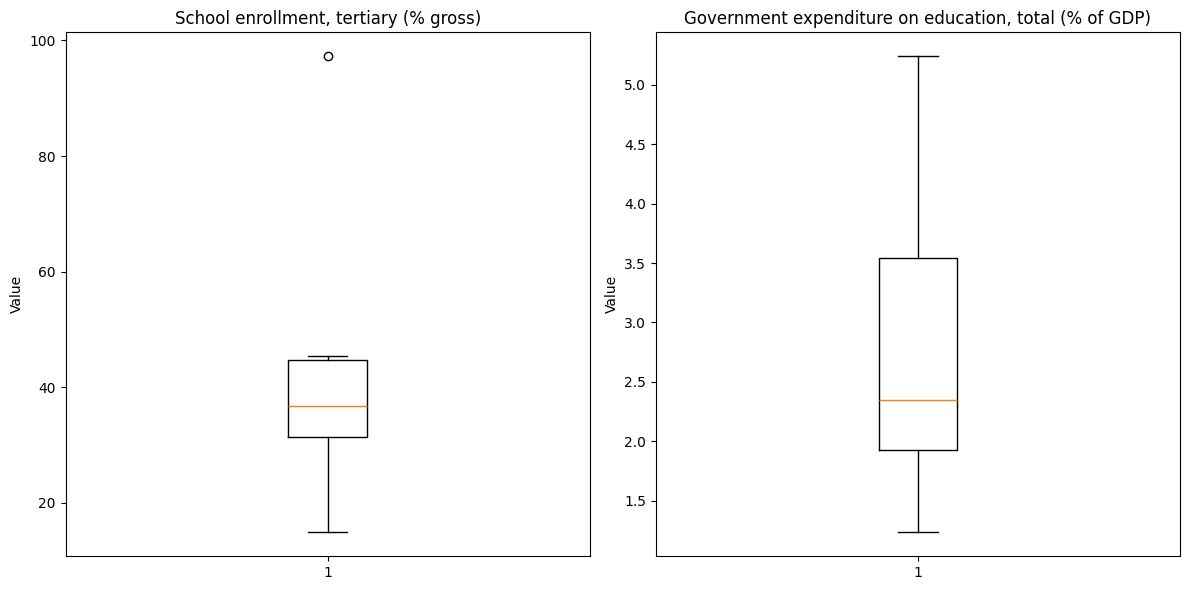

In [31]:
import matplotlib.pyplot as plt

# Columns School enrollment, tertiary (% gross) and Government expenditure on education, total (% of GDP)
cols_to_plot = [
    "School enrollment, tertiary (% gross)",
    "Government expenditure on education, total (% of GDP)"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 plots side by side

# Box plot for School enrollment, tertiary (% gross)
axes[0].boxplot(asean_latest[cols_to_plot[0]].dropna())
axes[0].set_title(cols_to_plot[0])
axes[0].set_ylabel("Value")

# Box plot for Government expenditure on education, total (% of GDP)
axes[1].boxplot(asean_latest[cols_to_plot[1]].dropna())
axes[1].set_title(cols_to_plot[1])
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

<p align="justify">
From the box plots above, School enrollment, tertiary (% gross) variable has outlier as can be seen by the small circle at the top part of the box plot. Meanwhile, Government expenditure on education, total (% of GDP) does not have any outlier. Therefore, missing values will be filled with median value for School enrollment, tertiary (% gross) and mean value will be used for Government expenditure on education, total (% of GDP) to replace the missing values. To obtain the mean and median value, it is advisable to display the statistical summary of the whole data. This can obtained by the code below:
</p>


In [32]:
#statistical summary of the data
asean_latest.describe()

,"Population, total",GDP (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)","Government expenditure on education, total (% of GDP)","School enrollment, tertiary (% gross)","Life expectancy at birth, total (years)"
count,1.100000e+01,1.100000e+01,11.000000,11.000000,8.000000,10.000000,11.000000
mean,6.274961e+07,3.459536e+11,14283.633425,32520.268493,2.717292,40.166604,72.824375
std,8.290404e+07,4.038753e+11,25268.754283,43519.177690,1.349859,22.721123,4.809075
min,4.589490e+05,2.079767e+09,1233.196662,4806.821816,1.233752,14.884170,66.889000
25%,6.791320e+06,2.908940e+10,2248.349166,8361.259724,1.929988,31.431211,69.398500
50%,3.512630e+07,3.999494e+11,4323.350320,15033.876859,2.351068,36.846427,71.146000
75%,8.602731e+07,4.712476e+11,9290.570436,29993.051796,3.542022,44.720833,75.869500
max,2.811901e+08,1.371169e+12,85412.230345,143786.136293,5.240528,97.288655,82.895122


<p align="justify">
Mean value for Government expenditure on education, total (% of GDP) can be obtained from the table above and median value for School enrollment, tertiary (% gross) is basically the second quartile (Q2) in the box plot which is actually the 50% value from the table above. The missing values in the latest dataframe will be replaced with mean and median values accordingly based on the variables. The fixed dataframe without missing values is display as below:
</p>

In [33]:
# Fill missing values
asean_latest["School enrollment, tertiary (% gross)"] = asean_latest[
    "School enrollment, tertiary (% gross)"
].fillna(asean_latest["School enrollment, tertiary (% gross)"].median())

asean_latest["Government expenditure on education, total (% of GDP)"] = asean_latest[
    "Government expenditure on education, total (% of GDP)"
].fillna(asean_latest["Government expenditure on education, total (% of GDP)"].mean())
asean_latest

,Country,"Population, total",GDP (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)","Government expenditure on education, total (% of GDP)","School enrollment, tertiary (% gross)","Life expectancy at birth, total (years)"
0,Brunei Darussalam,458949,1.509508e+10,32890.549181,85032.600874,2.717292,36.418273,75.327000
1,Cambodia,17423880,4.233565e+10,2429.748535,7430.730857,2.180913,17.436236,70.668000
2,Indonesia,281190067,1.371169e+12,4876.307745,15415.707926,1.275171,44.881303,71.146000
3,Lao PDR,7664993,1.584316e+10,2066.949798,9291.788590,1.233752,14.884170,68.964000
4,Malaysia,35126298,3.999494e+11,11386.039564,36466.891494,3.514800,37.274581,76.657000
5,Myanmar,54133798,6.675762e+10,1233.196662,5953.357352,2.717292,36.846427,66.889000
6,Philippines,114891199,4.370556e+11,3804.082741,10985.829263,3.623686,44.239420,69.833000
7,Singapore,5917648,5.054395e+11,85412.230345,143786.136293,2.148260,97.288655,82.895122
8,Thailand,71702435,5.159063e+11,7195.101309,23519.212098,2.521222,45.440781,76.412000
9,Timor-Leste,1384286,2.079767e+09,1502.411474,4806.821816,5.240528,30.961111,67.689000


<p align="justify">
Dataframe above is now fixed without any NaN values. However, it is worth to take note that replacing the missing values with mean or median means that the variables does not preserve relationship with other variables or in other words, the statistical relationship between these two variables and other variables are ignored.
</p>

## **Statistical Description of the Data**

<p align="justify">
Since the dataframe is now cleaned and wrangled, the statistical summary of the cleaned data is updated and it is shown as below:
</p>

In [34]:
#updated statistical summary of the data
asean_latest.describe()

,"Population, total",GDP (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)","Government expenditure on education, total (% of GDP)","School enrollment, tertiary (% gross)","Life expectancy at birth, total (years)"
count,1.100000e+01,1.100000e+01,11.000000,11.000000,11.000000,11.000000,11.000000
mean,6.274961e+07,3.459536e+11,14283.633425,32520.268493,2.717292,39.864770,72.824375
std,8.290404e+07,4.038753e+11,25268.754283,43519.177690,1.129373,21.578383,4.809075
min,4.589490e+05,2.079767e+09,1233.196662,4806.821816,1.233752,14.884170,66.889000
25%,6.791320e+06,2.908940e+10,2248.349166,8361.259724,2.164586,31.901312,69.398500
50%,3.512630e+07,3.999494e+11,4323.350320,15033.876859,2.717292,36.846427,71.146000
75%,8.602731e+07,4.712476e+11,9290.570436,29993.051796,3.116046,44.560362,75.869500
max,2.811901e+08,1.371169e+12,85412.230345,143786.136293,5.240528,97.288655,82.895122


<p align="justify">
Box plots for all 7 variables (indicators) are shown as below:
</p>

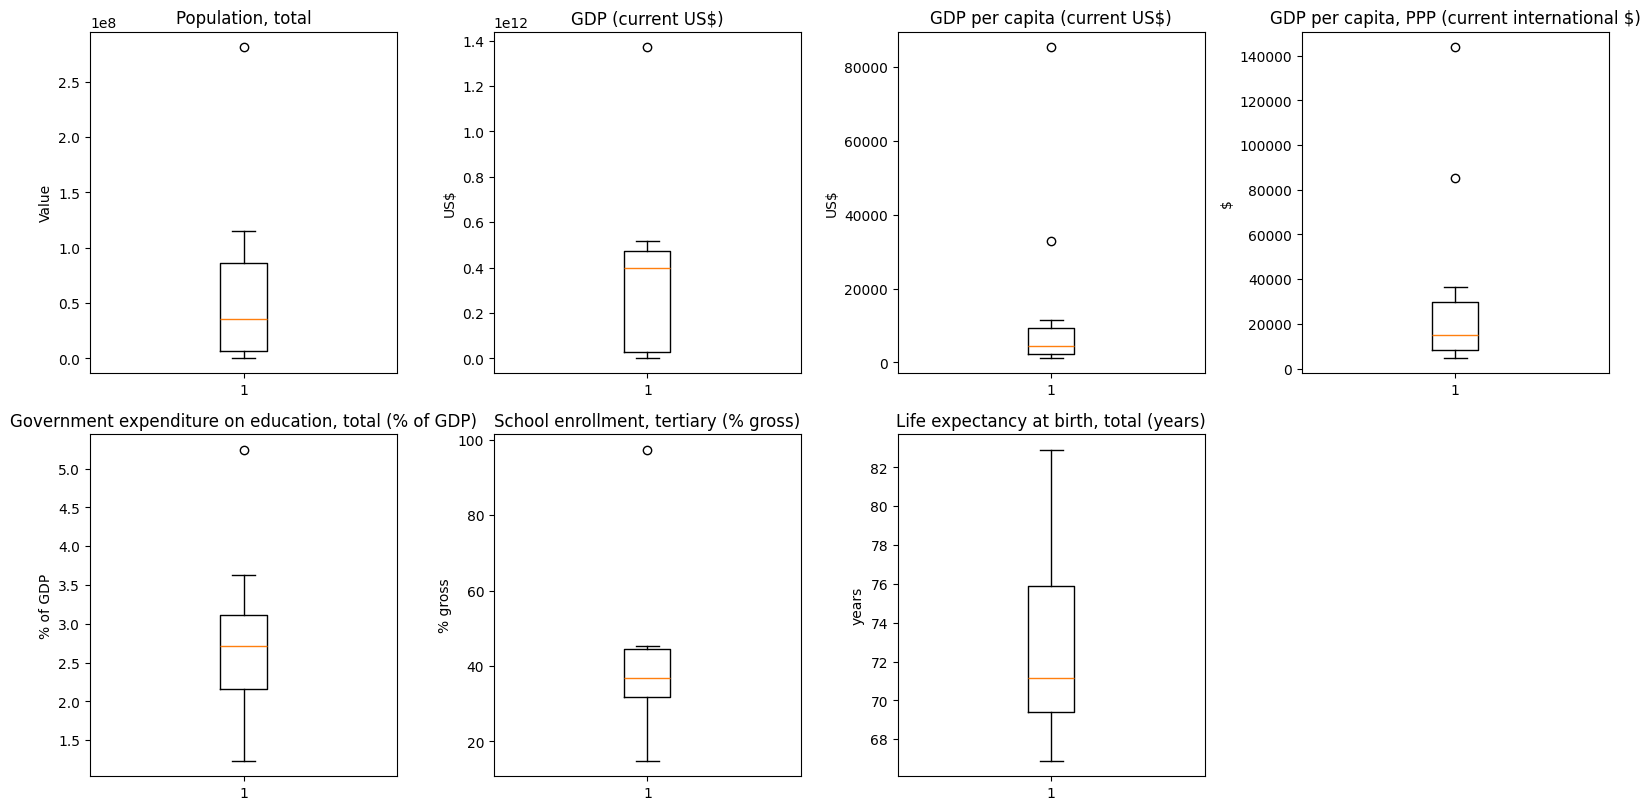

In [35]:
# Create subplots (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Column names and titles
titles = [
    "Population, total", "GDP (current US$)", "GDP per capita (current US$)",
    "GDP per capita, PPP (current international $)", "Government expenditure on education, total (% of GDP)",
    "School enrollment, tertiary (% gross)", "Life expectancy at birth, total (years)"
]
y_labels = [
    "Value", "US$", "US$", "$",
    "% of GDP", "% gross", "years"
]

# Define the columns to be used for the boxplots
# Assuming these are the desired columns from asean_latest
columns = [
    "Population, total", "GDP (current US$)", "GDP per capita (current US$)",
    "GDP per capita, PPP (current international $)", "Government expenditure on education, total (% of GDP)",
    "School enrollment, tertiary (% gross)", "Life expectancy at birth, total (years)"
]

# Plot each boxplot
for i, (col, title, y_label) in enumerate(zip(columns, titles, y_labels)):
    axes[i].boxplot(asean_latest[col])
    axes[i].set_title(title)
    axes[i].set_ylabel(y_label)

# Hide any unused subplots (if the grid has extra slots)
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

<p align="justify">
The statistical description of data for all 11 ASEAN member nations for the year 2023 that is sourced from WDI data from the World Bank dataset.  
</p>

<p align="justify">
For total population, the median (orange line) is toward the lower part of the distributiom. It also has a wide interquartile range (IQR) which suggest a wide distribution of the population sizes among countries. The upper whisker is longer indicates some countries with especially large populations. There is one outlier appears in the box plot and it is potentially Indonesia as it's population is way bigger in size compare to the other ASEAN countries    
</p>

<p align="justify">
Large IQR in GDP box plot suggesting that it has a wide distribution similar to total population. However, the median sits relatively low and the lower whisker are bigger compared to the upper whisker suggesting that there are few small economies below the median. An outlier in the box plot gives an insight that there is a country that has a very high GDP compare to other ASEAN countries (most likely Indonesia or Singapore).    
</p>

<p align="justify">
The distribution for GDP per capita is skewed to the right, with many ASEAN countries clustered as lower values and a few with much higher GDP per capita. There are two clear outliers that are far beyond the whisker potentially Singapore is one of them since the country has a very high GDP per capita. Narrow IQR compared to total GDP suggest low variation among most countries except the outliers. Hence, most ASEAN countries have modest GDP per capita, with one or two high-income outliers.
</p>

<p align="justify">
GDP per capita, PPP box plot has similar pattern as per the GDP per capita box plot. However, the values are a bit higher overall because PPP adjusts for cost of living. There are still outliers with one of them has very high PPP GDP per capita (likely Singapore). It has moderate IQR, some spread but not as extreme as total GDP. Overall, PPP adjustment raises the value but the variation remain persistent with GDP per capita with two outliers which have much higher PPP GDP per capita.
</p>

<p align="justify">
IQR is moderate in box plot of Government expenditure on education and the median is near the middle spending value. There is an outlier above the whisker which suggest that there is a country that spend more on its people's education compare to the rest of the ASEAN countries. Whiskers and spread suggest that most countries are clustered between lower and mid values of education spending. ASEAN countries typically spend similar portions of GDP towards education, with particulary one country invest a comparatively higher share.
</p>

<p align="justify">
From the tertiary school enrollment box plot, it has a very fair spread among all ASEAN countries and the median is a bit below that the main middle 50%. However, there is one distinct outlier above the box plot which means one country has much higher tertiary enrollment than the others. Hence, the enrollment rate in tertiary education is fairly the same across ASEAN, with one country significantly higher.
</p>

<p align="justify">
The median in the life expectancy box plot is lower than the middle value. However, the IQR is considerably very high which suggest a large variation on life expectancy among ASEAN member nations. The upper whisker is bigger compare to the lower part also suggest that they are more countries that have longer life expectancy with only few has low. There is no outlier observed in the box plot. Life expectancy among ASEAN countries has the most variation with more countries have higher life expectancy than other countries and no outlier gives an indication that no country has an abnormal life expectancy.
</p>

<p align="justify">
Overall, some indicators have very small IQR spread and some have wider IQR spread. Different spread size means different magnitude of variation among the ASEAN countries in each indicator. Majority of the indicators have one or two outliers which suggest that there are few countries that provides the number more than the majority of the ASEAN countries in certain indicators.
</p>

## **RESULTS AND DISCUSSION**

## **Population**

<p align="justify">
Display the total population by ASEAN countries and make comparison.
</p>

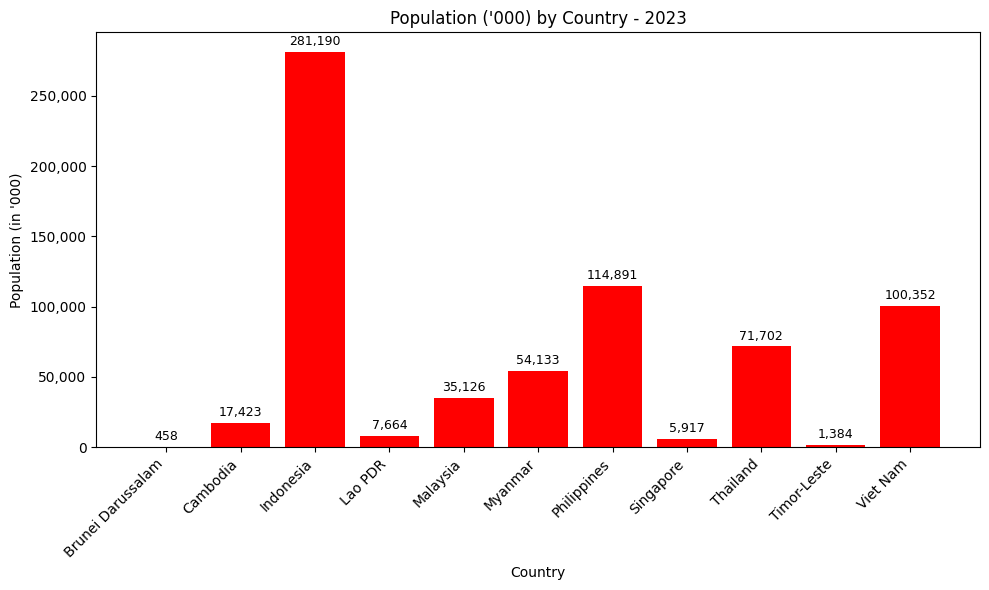

In [36]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))

# Plotting Population (total)
bars = plt.bar(asean_latest['Country'], asean_latest['Population, total'], color='red')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(asean_latest['Population, total']) * 0.01,  # slightly above bar
        f"{int(height/1000):,}",  # show in '000 (k) format
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Population ('000) by Country - 2023")
plt.xlabel("Country")
plt.ylabel("Population (in '000)")

# Scale y-axis to thousands
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000):,}"))

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<p align="justify">
In 2023, Indonesia dominates the total population massively among the ASEAN countries with 281,190,000 total population with Phillipines very far behind in second place which has total population of 114,891,000. Vietnam follow closely on third (100,352,000) with Thailand (71,702,000) and Myanmar (54,133,000) are the fourth and fifth largest ASEAN countries by population respectively. Malaysia has around 35 million population (35,126,000) and there are five countries that are consider as small nations in ASEAN, order by Cambodia (17,423,000), Lao PDR (7,664,000), Singapore (5,917,000), Timor-Leste (1,384,000) and Brunei Darussalam is the smallest nation by population where its total population does not even reach a one million mark (458,000). The total population share among ASEAN countries is shown in the pie chart below:
</p>

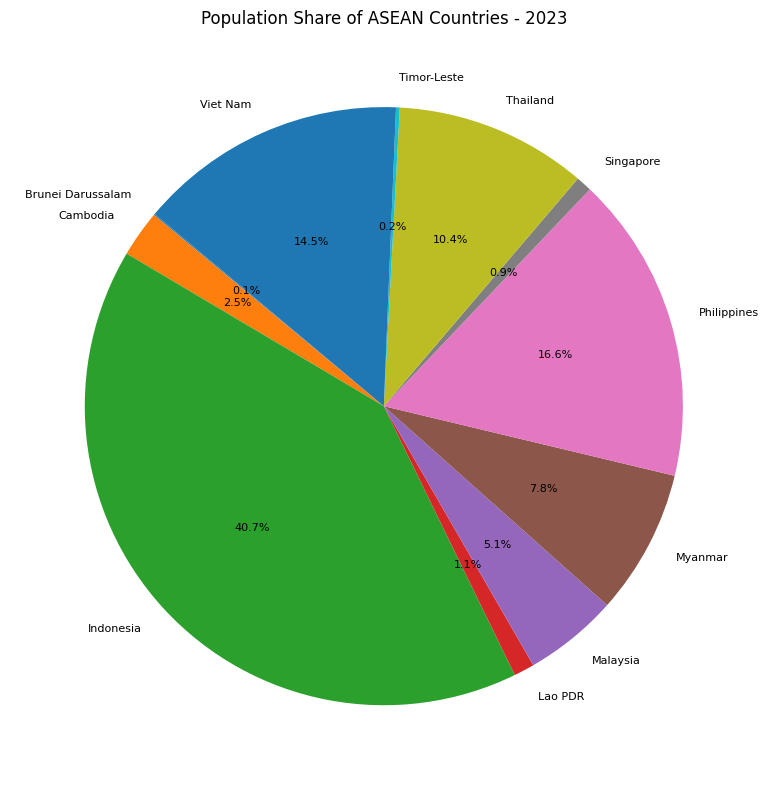

In [37]:
plt.figure(figsize=(8,8))
plt.pie(
    asean_latest['Population, total'],
    labels=asean_latest['Country'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 8}
)
plt.title('Population Share of ASEAN Countries - 2023')
plt.tight_layout()
plt.show()

<p align="justify">
The pie chart aboves visualize how Indonesia total population dominates almost half of the total ASEAN population in 2023 (40.7%). This number is reasonable considering how big Indonesia land is in the Southeast Asia region where it has around 1.9 million km<sup>2</sup> (worldometers). Phillipines (16.6%), Viet Nam (14.5%) and Thailand (10.4%) have population share of over 10% ASEAN population each. The rest of the nations have relatively low population share; Myanmar (7.8%), Malaysia (5.1%), Cambodia (2.5%), Lao PDR (1.1%), Singapore (0.9%), Timor-Leste (0.2%) and Brunei Darussalam (0.1%).
</p>

####**Reference:**
(worldometers) from https://www.worldometers.info/geography/largest-countries-in-the-world/

## **Economic Indicators (GDP, GDP per Capita and GDP per Capita, PPP)**

<p align="justify">
GDP for each ASEAN country is displayed to make comparison and this is shown by the bar plot below:
</p>

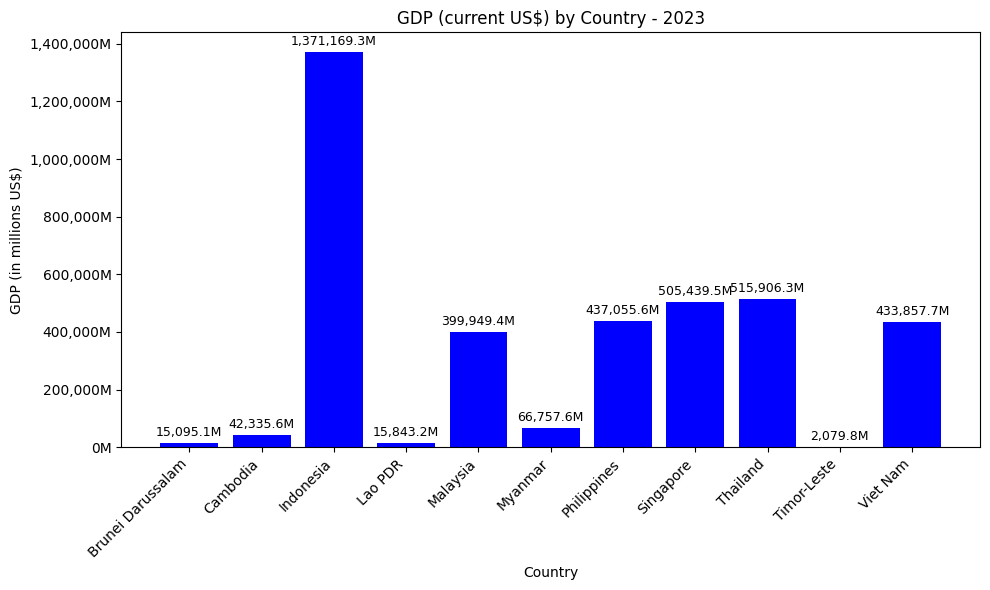

In [38]:
plt.figure(figsize=(10, 6))

# Plotting GDP (current US$)
bars = plt.bar(asean_latest['Country'], asean_latest['GDP (current US$)'], color='blue')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    # Format with commas, in millions (e.g., 1,234M)
    label = f"{height/1e6:,.1f}M"  # comma as thousands separator
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(asean_latest['GDP (current US$)']) * 0.01,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("GDP (current US$) by Country - 2023")
plt.xlabel("Country")
plt.ylabel("GDP (in millions US$)")

# Format y-axis tick labels with commas as thousands separators
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}M")
)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<p align="justify">
The bar plot aboves gives an insight on the total GDP by ASEAN country in 2023. Again, Indonesia's total GDP is the highest as compared to the other ASEAN member nations (1,371,169.3M US&#36;). The total GDP is more than double the total GDP of the ASEAN nation in second place, Thailand (515,906,3M US&#36;). Singapore (505,439.5M US&#36;), Phillipines (437,055.6M US&#36;), Viet Nam (433,857.7M US&#36;) and Malaysia (399,949.4M US&#36;) are behind Thailand. Myanmar (66,757.6M US&#36;) is the 7th highest ASEAN nation for total GDP followed by Cambodia (42,335.6M US&#36;), Lao PDR (15,843.2M US&#36;), Brunei Darussalam (15,095.1M US&#36;) and country with least total GDP, Timor-leste (2,079.8M US&#36;).
</p>

<p align="justify">
Country such as Indonesia which has the highest total population also has the largest total GDP. This is reasonable as higher population indicates more economic activities, more economic output thus, resulting in higher GDP. However, it is not always the case for other ASEAN countries. Singapore has higher total GDP than most of ASEAN countries even though its population is considerably small across the ASEAN member nations. Same goes to Brunei Darussalam, which is the smallest ASEAN nation by population but surpasses Timor-Leste in terms of total GDP. Therefore, total GDP is not the best indicator to compare economic output among ASEAN countries and this is where GDP per capita enters in which it takes into account the population of the countries as well. It measures the total GDP over the total population which will give the average economic output. The GDP per capita for each country is displayed below:
</p>

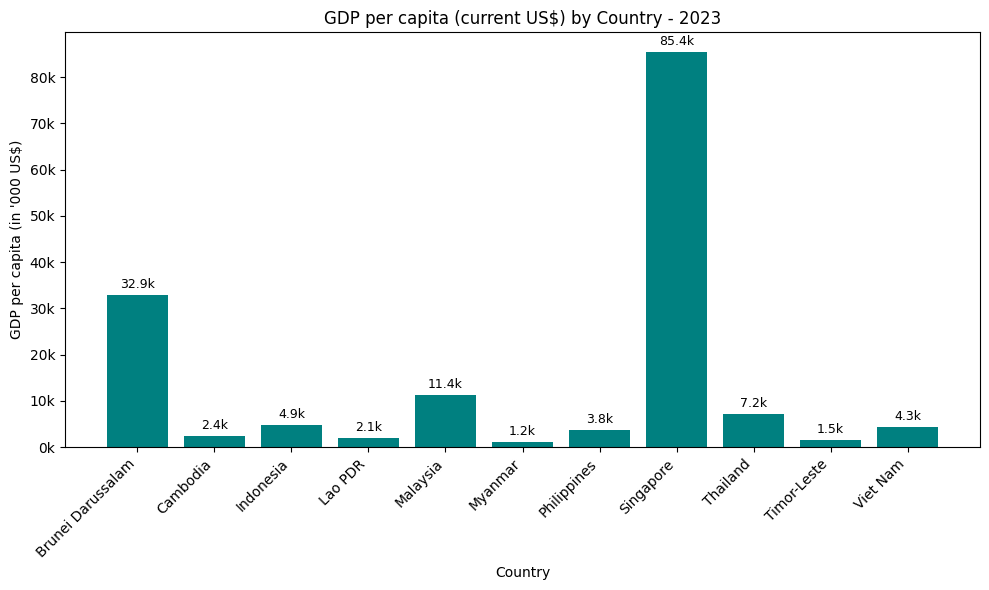

In [39]:
plt.figure(figsize=(10, 6))

# Plotting GDP per capita (current US$)
bars = plt.bar(asean_latest['Country'], asean_latest['GDP per capita (current US$)'], color='teal')

# Add value labels on top of each bar (in thousands)
for bar in bars:
    height = bar.get_height()
    label = f"{height/1000:,.1f}k"  # in thousands, comma as thousands separator
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(asean_latest['GDP per capita (current US$)']) * 0.01,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("GDP per capita (current US$) by Country - 2023")
plt.xlabel("Country")
plt.ylabel("GDP per capita (in '000 US$)")

# Format y-axis tick labels in thousands with commas
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:,.0f}k")
)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<p align="justify">
Singapore tops the list for GDP per capita in 2023 with a massive difference compare to other ASEAN countries with a whopping 85,400 US&#36; which is followed by Brunei Darussalam in second place (32,900 US&#36;). Malaysia is next with 11,400 US&#36; and Thailand (7,200 US&#36;) has the fourth highest GDP per capita. GDP per capita for Indonesia (4,900 US&#36;), Viet Nam (4,300 US&#36;) and Phillipines (3,800 US&#36;) are quite close with each other. Cambodia (2,400 US&#36;), Lao PDR (2,100 US&#36;), Timor-Leste (1,500 US&#36;) and Myanmar (1,200 US&#36;) fill in the bottom four for GDP per capita among ASEAN nations.
</p>

<p align="justify">
The GDP per capita bar plot above suggests that country with high total GDP does not guarantee it has a high GDP per capita as it is now taken into account the population of the country as well to find about the average economic output per person in the country. From the total GDP bar plot previously, Singapore competes with other nations such as Thailand, Viet Nam and Phillipine where total GDP between them is not far off each other. However, due to how small Singapore is, its GDP per capita far exceeds all other ASEAN countries. Same scenario goes for Brunei Darussalam, lower total GDP compare to others but has the second highest GDP per capita. This further suggests that population is vital to be taken into account in reviewing the whole economic performance of certain countries.
</p>

<p align="justify">
GDP per capita provides average economic output in the country (divide by total population). However, different country has different currency and the price levels in each country are varies as well. This is where Purchasing Power Parities (PPP) comes into play. PPP are the rates of currency conversion that eliminate the differences in price levels between countries (miti.gov). Therefore, to adjust to currency conversion we will plot GDP per capita and GDP per capita, PPP for all ASEAN countries together to spot any differences. Worth to take note that GDP per capita, PPP is measured in international &#36; (due to purchasing power parities rates) while GDP per capita is measured in US&#36;. The plot is shown below:
</p>

####**Reference:**
(miti.gov) from https://www.miti.gov.my/index.php/glossary/term/329

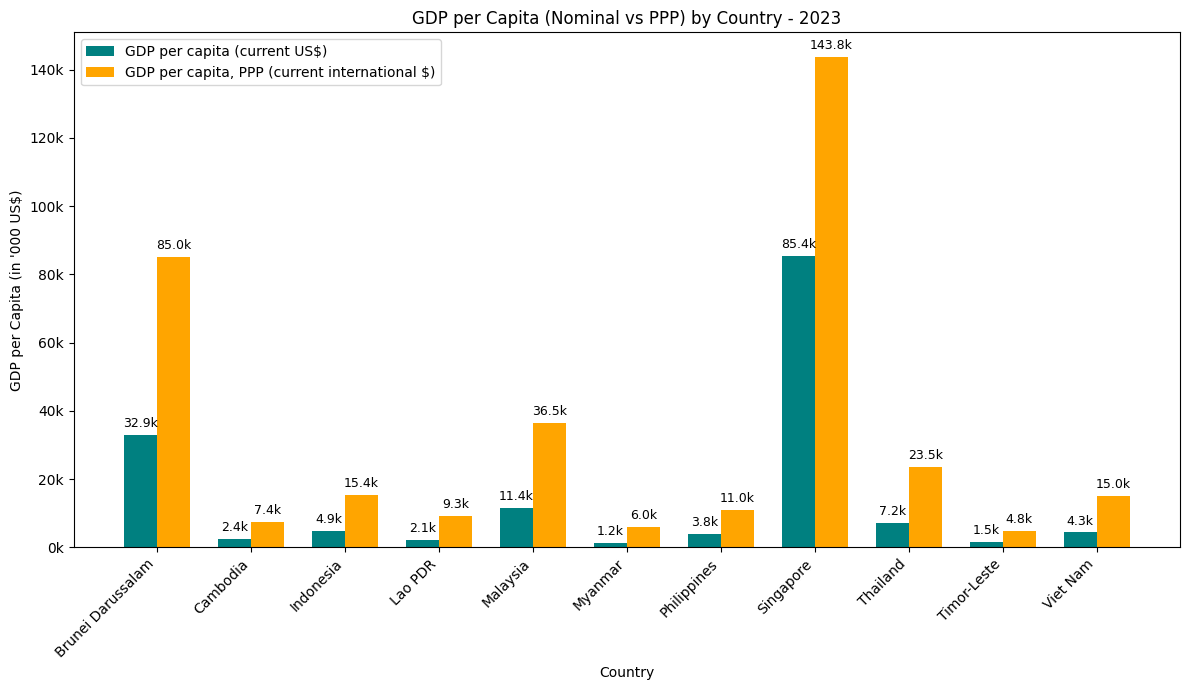

In [40]:
plt.figure(figsize=(12, 7))

# Set positions of bars on the x-axis
x = np.arange(len(asean_latest['Country']))
width = 0.35  # width of each bar group

# Plot bars
bars1 = plt.bar(
    x - width/2,
    asean_latest['GDP per capita (current US$)'],
    width,
    label="GDP per capita (current US$)",
    color='teal'
)
bars2 = plt.bar(
    x + width/2,
    asean_latest['GDP per capita, PPP (current international $)'],
    width,
    label="GDP per capita, PPP (current international $)",
    color='orange'
)

# Add value labels on top of each bar (in thousands, with commas)
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    label = f"{height/1000:,.1f}k"  # in thousands
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(
            asean_latest[['GDP per capita (current US$)',
                          'GDP per capita, PPP (current international $)']]
            .max()
        ) * 0.01,  # offset slightly above the bar
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

# Labels and titles
plt.xlabel("Country")
plt.ylabel("GDP per Capita (in '000 US$)")
plt.title("GDP per Capita (Nominal vs PPP) by Country - 2023")

# Format y-axis tick labels in thousands with commas
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:,.0f}k")
)

# Set x-axis ticks
plt.xticks(x, asean_latest['Country'], rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.show()

<p align="justify">
In terms of the GDP per capita, PPP for ASEAN countries, the order is almost similar as the nominal GDP per capita with Singapore has the highest GDP per capita, PPP (143,800 &#36;), followed by Brunei Darussalam (85,000 &#36;), Malaysia (36,500 &#36;), Thailand (23,500 &#36;), Indonesia (15,400 &#36;), Viet Nam (15,000 &#36;) and Phillipines (11,000 &#36;). Lao PDR ranks eighth among ASEAN countries for GDP per capita, PPP (9,300 &#36;).Cambodia (7,400 &#36;), Myanmar (6,000 &#36;) and Timor-Leste (4,800 &#36;) are the bottom three for this aspect.
</p>

<p align="justify">
Lao PDR is below Cambodia for GDP per capita but has higher GDP per capita, PPP than Cambodia. This suggests that while Lao PDR's average income measured at market exchange rates is lower, the actual purchasing power and real income of people in Laos when adjusted for the cost of living and local prices is relatively stronger than Cambodia's, indicating that goods and services may be cheaper or the standard of living within the country is comparatively better than nominal figures alone would imply. Same applies to Myanmar which is lower than Timor-leste for GDP per capita but is better in terms of GDP for capita PPP.
</p>

<p align="justify">
Comparing the GDP per capita and GDP per capita (PPP) from the plot above gives an insight that GDP per capita values are much lower than the GDP per capita (PPP). This is due to the fact that price levels in most developing countries are much cheaper. Therefore, the purchasing power in these developing countries is much higher compare to more developed countries (Paul and Francette, 2002). Since majority of ASEAN countries are developing countries, thus explaining on why GDP per capita (PPP) are much higher than the nominal GDP per capita.
</p>

####**Reference:**
 Paul Schreyer and Francette Koechlin (2002). Purchasing power
parities – measurement and uses

## **Education Indicators (Government Expenditure on Education and Tertiary School Enrollment)**

<p align="justify">
Government expenditure on education for all ASEAN countries in 2023 is plot and visualize to make comparison between countries. The plot is shown below:
</p>

/tmp/ipython-input-3807314228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


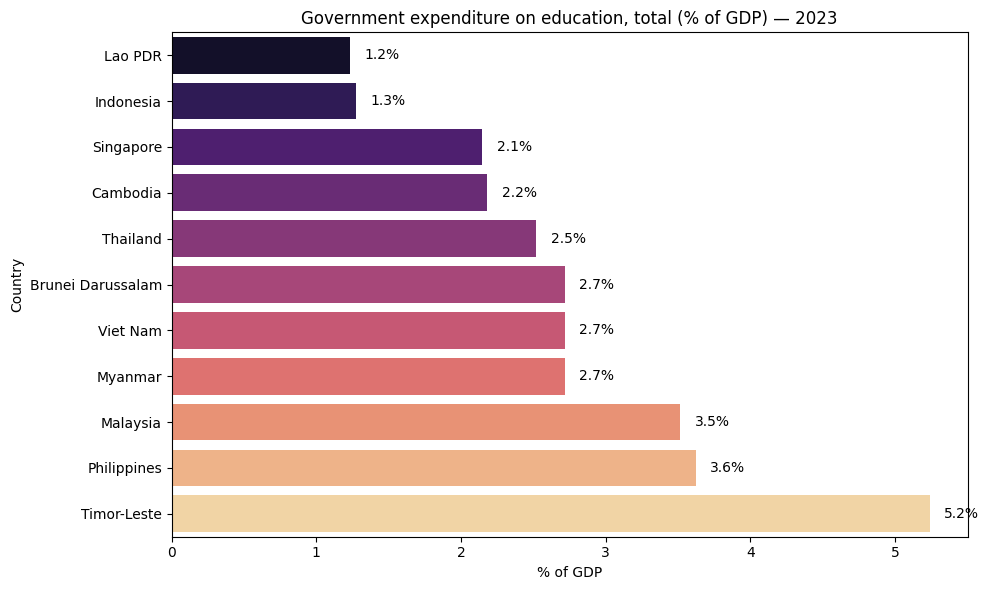

In [41]:
plt.figure(figsize=(10, 6))

# Sort values
sorted_df = asean_latest.sort_values('Government expenditure on education, total (% of GDP)')

# Create barplot
ax = sns.barplot(
    x='Government expenditure on education, total (% of GDP)',
    y='Country',
    data=sorted_df,
    palette='magma'
)

# Add value labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.1,              # position slightly after the bar
        p.get_y() + p.get_height() / 2,
        f"{width:.1f}%",          # format with one decimal place
        ha='left',
        va='center'
    )

plt.title('Government expenditure on education, total (% of GDP) — 2023')
plt.xlabel('% of GDP')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

<p align="justify">
For the plot above, it is worth to take note that Brunei Darussalam, Viet Nam and Myanmar's datas use mean value for the plot due to missing values in the initial WDI dataset. Also, the data is measured in percentage of GDP which means how much GDP's proportion that each country spend on education. Higher percentage does not mean higher amount in terms of monetary value for education expenditure, it is more about how important each country view education and the need for each nation's government to improve education in their respective countries.
</p>

<p align="justify">
From the horizontal bar plot above, Timor-Leste has the highest percentage in terms of education's financial support from the government with 5.2% of its GDP. This is followed by Phillipines and Malaysia government in which they spend 3.6% and 3.5% of their respective GDP towards education. Myanmar, Viet Nam and Brunei Darussalam have mean values of 2.7% of GDP on the education expenditure. Thailand government spent 2.5%, followed by Cambodia (2.2%) and Singapore (2.1%) with Indonesia (1.3%) and Lao PDR (1.2%) allocate their GDP the least towards education.   
</p>

<p align="justify">
Timor-Leste government allocation of 5.2% of its GDP towards education is consider quite high as compared to other ASEAN countries who spend typically less than 4% of GDP. This happened due to Timor-Leste stategic development plan 2011 - 2023 where it emphasies 'social capital' (education and health) as top priority to achieve sustainable development. Timor-Leste's Ministry of Education spent the budget towards infrastrustue and capital development which include new school, improve facilities and teacher trainings to name a few (STRATEGIC DEVELOPMENT PLAN). Historically, Timor-Leste spent more on education with about 7.7% of budget is spent on education in 2017. However, this number decreases over time due to the perception that available resources were not efficiently spent and in part a reprioritisation of the national budget due to COVID-19 (Aashna, Yang and Olya 2025).
</p>

####**References:**
(STRATEGIC DEVELOPMENT PLAN) TIMOR-LESTE STRATEGIC DEVELOPMENT PLAN 2011 - 2030  from https://timor-leste.gov.tl/wp-content/uploads/2012/02/Strategic-Development-Plan_EN.pdf

Aashna Jamal, Yang Liu and Olya Homonchuk (2025) Joining up data to inform budget negotiations in Timor-Leste's education sector from https://odi.org/en/insights/joining-up-data-to-inform-budget-negotiations-in-timor-lestes-education-sector/#:~:text=Result:%20short%2Dterm%20budgetary%20gains,grants%20and%20improvements%20to%20infrastructure.

<p align="justify">
Add in the Tertiary School Enrollment for each ASEAN country to the government expenditure on education plot will give an overview of how expenditure on education reflects towards the Tertiary School Enrollment. The plot is shown as below:
</p>

/tmp/ipython-input-2821950217.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


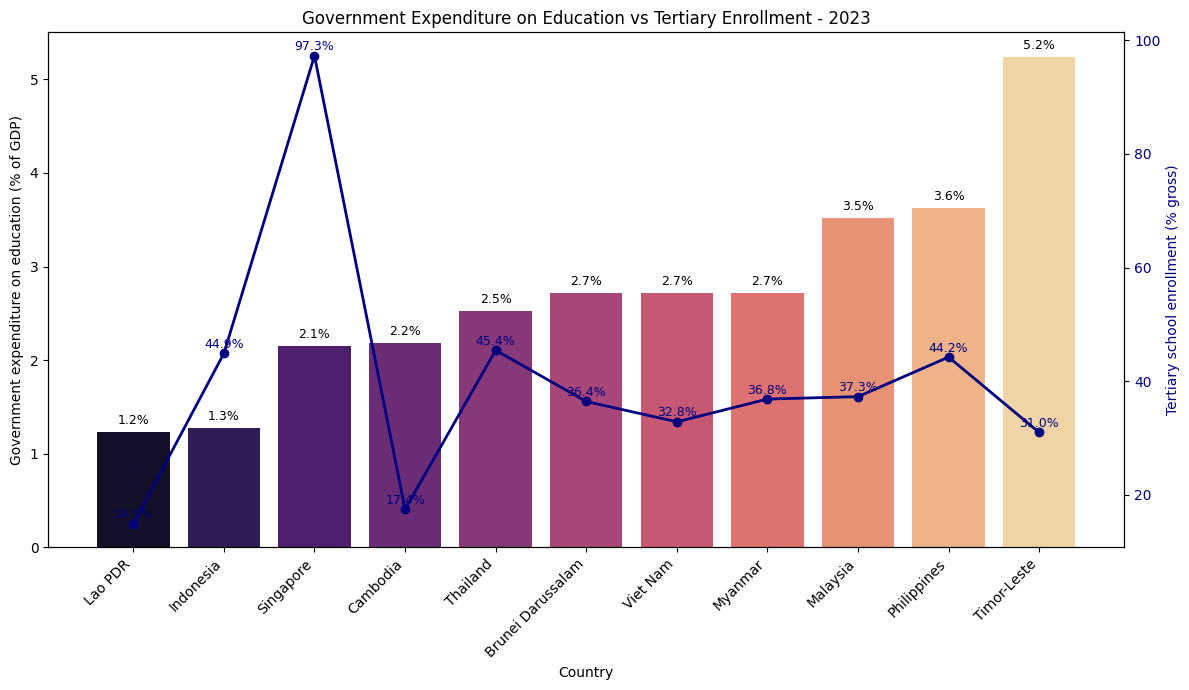

In [42]:
plt.figure(figsize=(12, 7))

# Sort DataFrame by Government expenditure
sorted_df = asean_latest.sort_values('Government expenditure on education, total (% of GDP)')

# Primary axis for vertical bar chart
ax1 = plt.gca()

# Vertical bar chart for Government Expenditure
sns.barplot(
    x='Country',
    y='Government expenditure on education, total (% of GDP)',
    data=sorted_df,
    palette='magma',
    ax=ax1
)

# Add labels above bars
for p in ax1.patches:
    height = p.get_height()
    ax1.text(
        p.get_x() + p.get_width() / 2,
        height + sorted_df['Government expenditure on education, total (% of GDP)'].max() * 0.01,
        f"{height:,.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax1.set_xlabel("Country")
ax1.set_ylabel("Government expenditure on education (% of GDP)")
ax1.set_title("Government Expenditure on Education vs Tertiary Enrollment - 2023")

# Rotate x-axis labels 45°
plt.xticks(rotation=45, ha='right')


# Secondary axis for the trend line
ax2 = ax1.twinx()

# The trend line for Tertiary School Enrollment
ax2.plot(
    sorted_df['Country'],
    sorted_df['School enrollment, tertiary (% gross)'],
    color='navy',
    marker='o',
    linewidth=2,
    label="Tertiary school enrollment (% gross)"
)

# Point labels for the trend line
for x, y in zip(sorted_df['Country'], sorted_df['School enrollment, tertiary (% gross)']):
    ax2.text(
        x,
        y + sorted_df['School enrollment, tertiary (% gross)'].max() * 0.01,
        f"{y:,.1f}%",
        color='navy',
        fontsize=9,
        ha='center'
    )

ax2.set_ylabel("Tertiary school enrollment (% gross)", color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<p align="justify">
Tertiary School Enrollment is measured in % gross, in which it does not reflect the total number of students enrolled in tertiary education, instead it is the percentage of enrolled tertiary students compared to the population of the official age group for tertiary education based on each country system (typically age 18-22).
</p>

<p align="justify">
Tertiary School Enrollment is displayed as the trendline in above plot. In 2023, Singapore has the highest tertiary school enrollment with an impressive 97.3%. Thailand is has the second highest tertiary enrollment (45.5%), followed closely by Indonesia (44.9%) and Phillipines (44.2%). Malaysia is next with 37.3%, Myanmar (36.8%), Brunei (36.4%), Viet Nam (32.8%) and Timor-Leste (31.0%) all has more than 30% tertiary enrollment rate. Cambodia and Lao PDR are the lowest two nations with each has 17.4% and 14.9% for tertiary school enrollmnet rate respectively.
</p>

<p align="justify">
Comparing government expenditure on education and tertiary school enrollment by each ASEAN member nations does not imply any significant relationship between two indicators. Higher percentage of GDP spent on education does not guarantee that higher tertiary enrollment rate based on the plot above. Even though Timor-Leste spent more percentage of its GDP towards education, its tertiary school enrollment is still behind a lot of other ASEAN members. On the other hand, Singapore is one of the lowest when it comes to allocation of GDP towards education but still managed to top tertiary enrollment rate with a massive percentage value.
</p>

<p align="justify">
There are several reasons why the perception exists that higher government spending on education (as a percentage of GDP) may be associated with a higher tertiary enrollment rate in the context of these WDI indicators is a wrong perception. First of all, the metric used for government spending on education is the percentage of GDP. 5.2% of GDP allocated by Timor-Leste towards education looks like a high proportion when in reality, the monetary value is less than other nations. This is due to the fact that Timor-Leste's GDP is way below among other ASEAN countries. In terms of monetary value, 5% of the Timor-Leste's GDP is still less than 3% of other countries with super high GDP such as Indonesia. That's why this indicator's metric cannot be a benchmark to use for this comparison.
</p>

<p align="justify">
Metric used for tertiary school enrollment based on WDI also is not a great metric to compare with other variables. This is due to the fact that it takes into account percentage of enrolled tertiary students compared to the population of the official age group. In Singapore for instace, the population is quite low compare to other countries. This means that the tertiary official age group is low as well in the country. If the amount of tertiary enrolled students are similar in Singapore and another nation with larger population, the tertiary enrolled student will be higher in Singapore compare to the larger nation. Hence, the reason why the tertiary school enrollment indicator measured as per the WDI dataset deem to be not really reliable.
</p>

<p align="justify">
Another potential reason on why government expenditure on education does not  impact towards tertiary school enrollment is due to external factors. People's mindset towards furthering studies and financial constraint to afford tertiary education to name a few can be the stumbling block even if country has spend to provide a better education platform; whether in terms of better infrastructure, better training to the educationer and better education equipment.
</p>

<p align="justify">
Singapore's high tertiary enrollment rate is not a coincidence. The government has help a lot towards education development in the country. Through number of policy innovations implemented, strengthen the quality of instruction, aiding low income student as well as lessons for educational practitioners established Singapore as among the top performers in the world on a number of educational metrics (Daniel C. Kent).
</p>

####**Reference:**
(Daniel C. Kent) A NEW EDUCATIONAL PERSPECTIVE: THE CASE OF SINGAPORE from https://files.eric.ed.gov/fulltext/EJ1160443.pdf

## **GDP per Capita towards Tertiary School Enrollment**

<p align="justify">
Tertiary school enrollment is plotted together with GDP per capita to see if there is any potential relationship between the education and the economic indicators. The plot for each ASEAN countries is shown below:
</p>

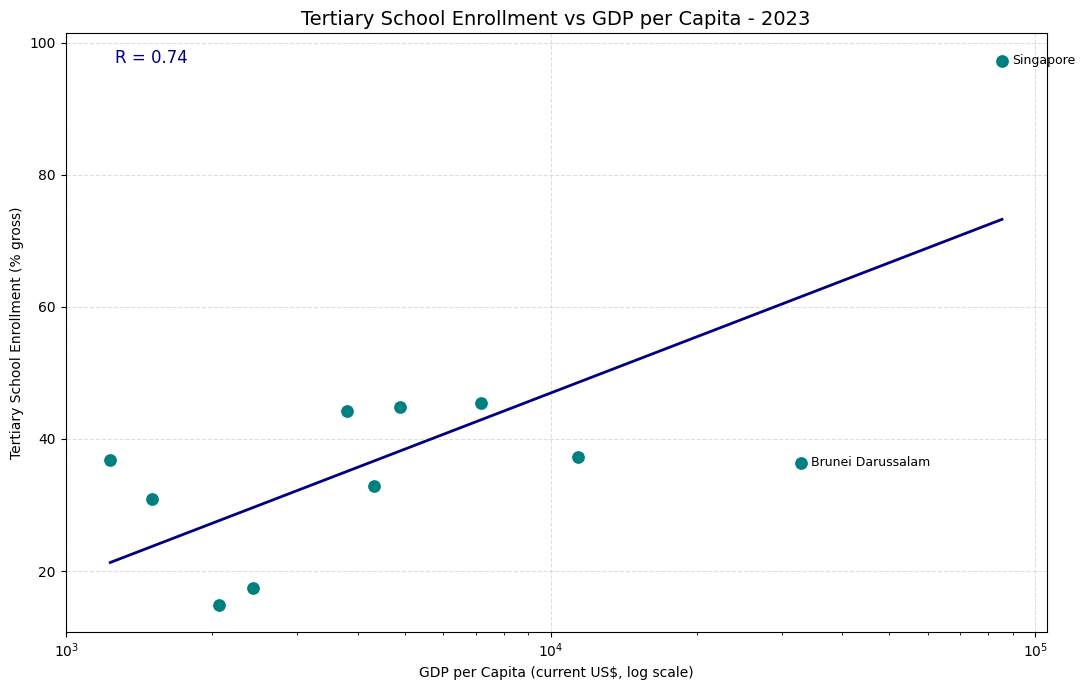

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

plt.figure(figsize=(11, 7))

# Scatter with log x-axis
sns.scatterplot(
    data=asean_latest,
    x='GDP per capita (current US$)',
    y='School enrollment, tertiary (% gross)',
    s=100,
    color='teal'
)

# Log scale for x
plt.xscale('log')

# Fit regression on log(x)
x = np.log10(asean_latest['GDP per capita (current US$)'])
y = asean_latest['School enrollment, tertiary (% gross)']
slope, intercept, r, p, se = linregress(x, y)

# Regression line
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = intercept + slope * x_vals
plt.plot(10**x_vals, y_vals, color='navy', lw=2)

# Annotation: correlation
plt.text(
    0.05, 0.95,
    f"R = {r:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    color='navy'
)

# Optional selective labels for clarity
for i, row in asean_latest.iterrows():
    if row['School enrollment, tertiary (% gross)'] > 60 or row['GDP per capita (current US$)'] > 20000:
        plt.text(
            row['GDP per capita (current US$)']*1.05,
            row['School enrollment, tertiary (% gross)'],
            row['Country'],
            fontsize=9,
            ha='left',
            va='center'
        )

# Titles and formatting
plt.title("Tertiary School Enrollment vs GDP per Capita - 2023", fontsize=14)
plt.xlabel("GDP per Capita (current US$, log scale)")
plt.ylabel("Tertiary School Enrollment (% gross)")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

<p align="justify">
For the plot above, few tweaks have been made to make the plot look more presentable. GDP per capita is log scaled since it ranges from a few hundred to tens of thousands. Using log scale spreads points out nicely. Only few labels are selected in which this case are GDP per capita for Singapore and Brunei Darussalam as labelled in the plot above. The conditions for the selected labels are tertiary enrollment rate of more than 60% and GDP per capita of more than 20,000 US&#36. This reduces clutter but keeps insight. The top left of the plot shows the strength of the relationship denoted with R. In this case, the R value is 0.74 which correspond to strong relationship.
</p>

<p align="justify">
From the linear regression plot above, it shows that there is positive linear relationship between GDP per capita and tertiary school environment. However, the significance of the predictor (GDP per capita) cannot be extracted solely based on the plot itself. Hence, the p-value for the predictor is calculated using Ordinary Least Squared (OLS) regression. For this case, the hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is GDP per capita.
</p>

In [44]:
import statsmodels.api as sm

# Define X and Y
X = asean_latest['GDP per capita (current US$)']
y = asean_latest['School enrollment, tertiary (% gross)']

# Add constant (intercept)
X_with_const = sm.add_constant(X)

# Fit linear regression
model = sm.OLS(y, X_with_const).fit()

print(model.summary())

                                      OLS Regression Results                                     
Dep. Variable:     School enrollment, tertiary (% gross)   R-squared:                       0.740
Model:                                               OLS   Adj. R-squared:                  0.711
Method:                                    Least Squares   F-statistic:                     25.57
Date:                                   Sat, 03 Jan 2026   Prob (F-statistic):           0.000684
Time:                                           09:29:32   Log-Likelihood:                -41.471
No. Observations:                                     11   AIC:                             86.94
Df Residuals:                                          9   BIC:                             87.74
Df Model:                                              1                                         
Covariance Type:                               nonrobust                                         
                    

<p align="justify">
The OLS regression results from the table above provide several insights into the relationship between 'GDP per capita (current US&#36)' and 'School enrollment, tertiary (% gross)'. R-squared value is 0.740. This means that 74.0% of the variation in 'School enrollment, tertiary (% gross)' can be explained by 'GDP per capita (current US&#36)'. 'GDP per capita (current US&#36)' has very low p-value (0.001), which is less than the conventional significance level of 0.05. This means that the null hypothesis is rejected. Therefore, 'GDP per capita (current US&#36)' is statistically significant predictor in the model.
</p>

<p align="justify">
In summary, the regression analysis suggests a statistically significant positive relationship between a country's GDP per capita and its tertiary school enrollment rate among ASEAN nations in 2023. As GDP per capita increases, tertiary school enrollment tends to increase.
</p>


## **Health Indicator (Life Expectancy) Analysis**

<p align="justify">
Moving on to the selected health indicator from WDI dataset; life expectancy. The life expecatancy for all ASEAN nations in 2023 is plotted as per below:
</p>

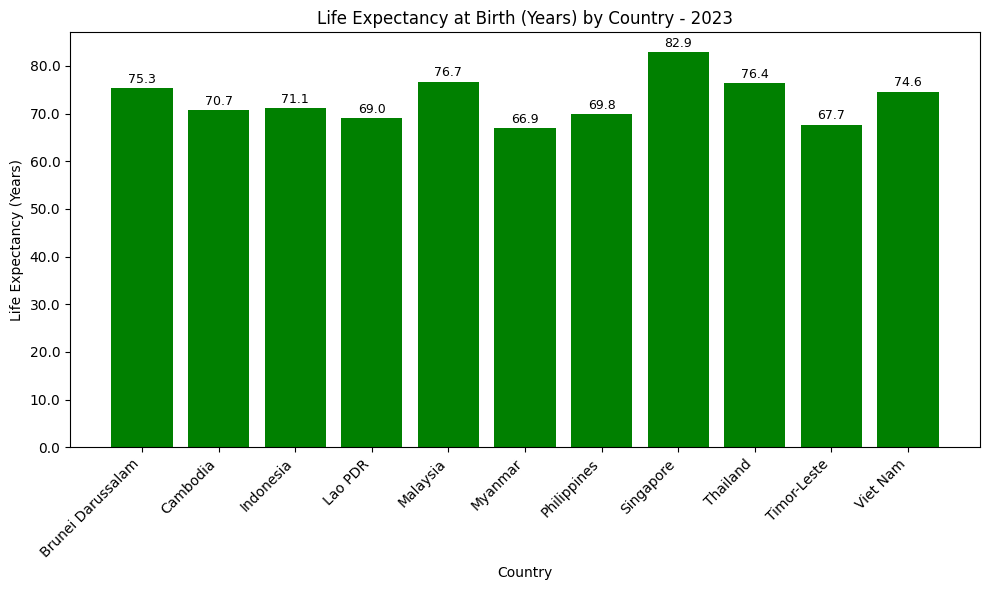

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))

# Plotting Life expectancy at birth, total (years)
bars = plt.bar(asean_latest['Country'], asean_latest['Life expectancy at birth, total (years)'], color='green')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    label = f"{height:.1f}"  # one decimal point
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,  # small offset above bar
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Life Expectancy at Birth (Years) by Country - 2023")
plt.xlabel("Country")
plt.ylabel("Life Expectancy (Years)")

# Format y-axis tick labels with one decimal place
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<p align="justify">
From the plot above, Singapore has the highest life expectancy with 82.9 years. Malaysia (76.7 years), Thailand (76.4 years), Brunei Darussalam (75.3 years), Viet Nam (74.6 years), Indonesia (71.1 years) and Cambodia (70.7 years) all have life expectancy above 70 years. Phillipines (69.8 years), Lao PDR (69.0 years), Timor-Leste (67.7 years) and Myanmar (66.9 years) are the nations with life expecatancy less than 70 years.
</p>

<p align="justify">
Singapore top the life expectancy by quite significant years compare to other ASEAN nations. This is due to how the country value the quality of life. The  government's gradual policy changes have affect its citizens' health and wellness. Heavy taxation on cigarettes and alcohol coupled with stringent public smoking bans, not only improves individual health but also enhances public spaces, making them more welcoming and cleaner (Lindsey, 2025). Measures like mandatory nutritional labelling and the reduction of sugar content in beverages have made a noticeable difference in public health awareness and choices (Lindsey, 2025). Singapore's healthcare system has also received global accolades for both its quality of care and its ability to keep costs contained (Lindsey, 2025). Other policies like robust public transportation encourage walking and daily exercise, while a prioritisation on keeping the country clean and beautiful also gives residents a sense of security and calm (Lindsey, 2025). Hence, why Singapore has the highest life expectancy among ASEAN countries.
</p>

####**Reference:**
(Lindsey Galloway) 2025 The world's sixth 'Blue Zone': Why Singapore values both quantity and quality of life from https://www.bbc.com/travel/article/20241002-singapore-

## **GDP per Capita towards Life Expectancy**

<p align="justify">
GDP per capita is plotted together with life expecatncy to see if there is any potential relationship between the health and the economic indicators. The plot is shown below:
</p>

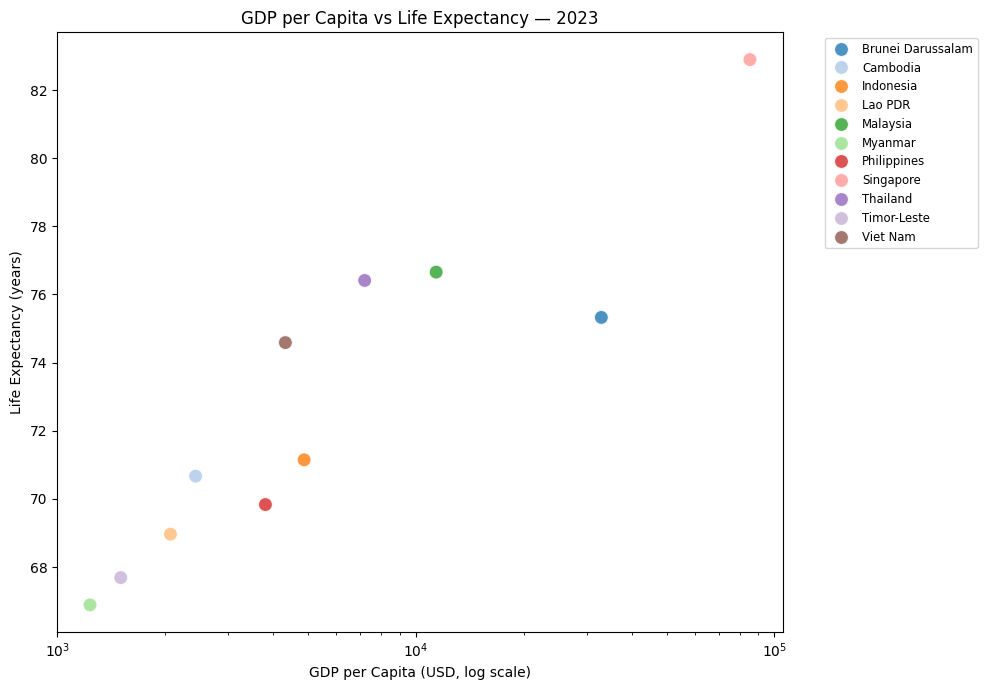

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

# Define a palette with exactly 11 distinct colors
palette = sns.color_palette("tab20", 11)

sns.scatterplot(
    data=asean_latest,
    x='GDP per capita (current US$)',
    y='Life expectancy at birth, total (years)',
    hue='Country',            # color by country
    palette=palette,          # 11 distinct colors
    s=100,
    alpha=0.8
)

plt.xscale('log')  # log scale
plt.title('GDP per Capita vs Life Expectancy — 2023')
plt.xlabel('GDP per Capita (USD, log scale)')
plt.ylabel('Life Expectancy (years)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

<p align="justify">
For the plot above, GDP per capita is log scaled since it ranges from a few hundred to tens of thousands. Using log scale spreads points out nicely. The plot aboves give an insight about the increasing pattern that is observed from the plot. An increase in GDP per capita (log scale) correspond to increase in Life Expectancy. However, this relationship is not statistically proven yet therefore, OLS regression analysis for this relationship will be test first. In this case, GDP per capita acts as the predictor, $\beta_1$
</p>

<p align="justify">
For this case, the hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$
</p>

In [47]:
import statsmodels.api as sm

# Define X and Y
X = asean_latest['GDP per capita (current US$)']
y = asean_latest['Life expectancy at birth, total (years)']

# Add constant (intercept)
X_with_const = sm.add_constant(X)

# Fit linear regression
model = sm.OLS(y, X_with_const).fit()

print(model.summary())

                                       OLS Regression Results                                      
Dep. Variable:     Life expectancy at birth, total (years)   R-squared:                       0.639
Model:                                                 OLS   Adj. R-squared:                  0.599
Method:                                      Least Squares   F-statistic:                     15.96
Date:                                     Sat, 03 Jan 2026   Prob (F-statistic):            0.00313
Time:                                             09:29:46   Log-Likelihood:                -26.749
No. Observations:                                       11   AIC:                             57.50
Df Residuals:                                            9   BIC:                             58.29
Df Model:                                                1                                         
Covariance Type:                                 nonrobust                                         


<p align="justify">
The OLS regression results from the table above provide several insights into the relationship between 'GDP per capita (current US&#36)' and 'Life expectancy at birth, total (years)'. R-squared value is 0.639. This means that 63.9% of the variation in 'Life expectancy at birth, total (years)' can be explained by 'GDP per capita (current US&#36)'. 'GDP per capita (current US&#36)' has very low p-value (0.003), which is less than the conventional significance level of 0.05. This means that the null hypothesis is rejected. Therefore, 'GDP per capita (current US&#36)' is statistically significant predictor in the model.
</p>

<p align="justify">
In summary, the regression analysis suggests a statistically significant positive relationship between a country's GDP per capita and its Life expectancy at birth among ASEAN nations in 2023. As GDP per capita increases, life expectancy tends to increase.
</p>

### **CONCLUSION**

<p align="justify">
There are a lot of things discovered in this project. Comparison of economic indicators (GDP, GDP per capita and GDP per capita (PPP)) provides a useful insight on how high GDP does not indicate the real economic output without consideration of the total population. This is where GDP per capita came into play. GDP per capita showed how Singapore dominates even though it is a small nation. GDP per capita (PPP) is adjusted through currency rate conversion and eliminate the price levels among the ASEAN countries.  
</p>

<p align="justify">
Education indicators (Government Expenditure on Education and Tertiary School Enrollment) shows how each ASEAN nations contribute towards its education and discovered Timor-Leste's allocation of its GDP towards education in their country. From this section, we also discovered that government expenditure on education does not guarantee good tertiary enrollment rate due to certain limitations and external factors. This is where this project can be further developed by choosing a more suitable education indicator rather than the selected ones.
</p>

<p align="justify">
Life expectancy (health indicator) shows how each ASEAN nations compared between them. Singapore has the highest life expectancy among ASEAN nations due to its multiple health policies towards achieving good quality of life. There are also two distinct linear relationships discovered in this project where it is established that GDP per capita statistically has linear relationship with both tertiary enrollment rate and life expectancy.
</p>

<p align="justify">
Overall, hopefully this project will give useful insights on the comparison among all ASEAN nations on certain selected indicators and provide a platform to discover more suitable indicators for future analysis or project.
</p>